In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import mglearn 
import tensorflow as tf 
from sklearn.datasets import fetch_lfw_people 
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Dense

In [3]:
np.random.seed(180) 
tf.random.set_seed(180) 

(3023, 5655)
(3023,)


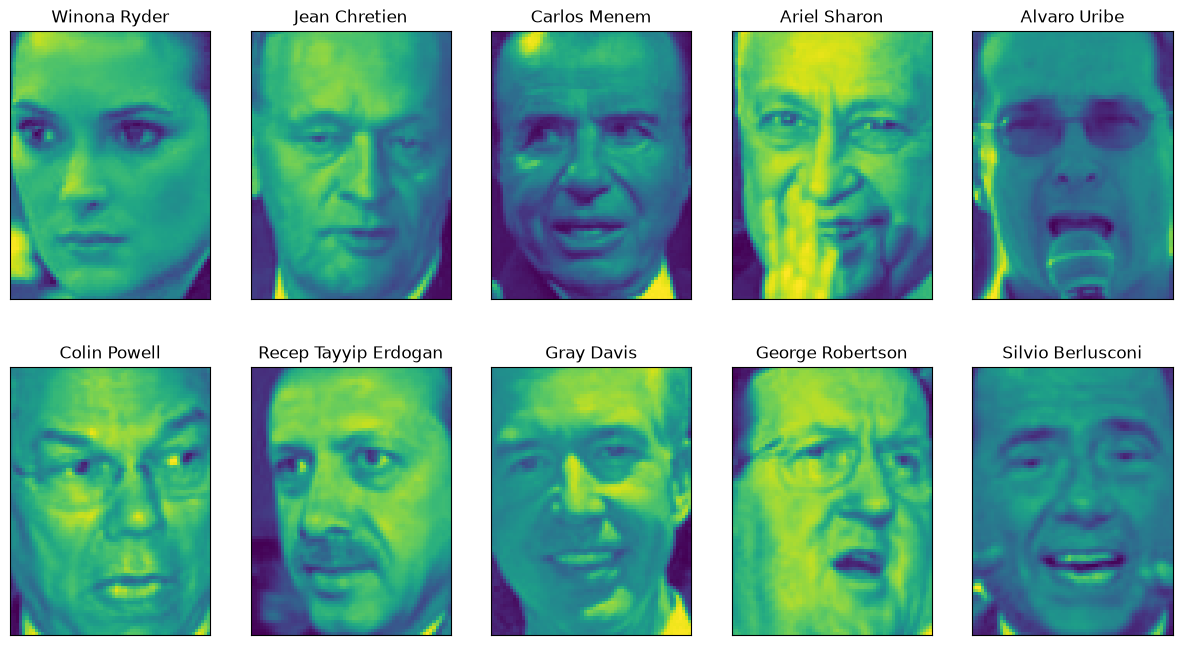

In [8]:
people = fetch_lfw_people( 
min_faces_per_person=20, 
resize=0.7 
) 
print(people.data.shape) 
print(people.target.shape) 
image_shape = people.images[0].shape 
fix, axes = plt.subplots( 
2, 
5, 
figsize=(15,8), 
subplot_kw={'xticks':(), 'yticks':()} 
) 
for target, image, ax in zip( 
people.target, 
people.images, 
axes.ravel()): 
 ax.imshow(image) 
 ax.set_title( 
        people.target_names[target] 
    ) 
 
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split( 
    people.data, 
    people.target, 
    test_size=0.2, 
    random_state=20 
) 
 
y_train = y_train.astype(int) 
y_test = y_test.astype(int) 
 
batch_size = len(X_train) 
 
print( 
    X_train.shape, 
    y_train.shape, 
    y_test.shape 
) 
 
print( 
    "people.images.shape: {}".format( 
        people.images.shape 
    ) 
) 
 
print( 
    "Number of classes: {}".format( 
        len(people.target_names) 
    ) 
)

(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [11]:
count = np.bincount(people.target) 
 
for i, (count, name) in enumerate( 
        zip(count, people.target_names)): 
 
    print( 
        "{0:25} {1:3}".format(name,count), 
        end=" " 
    ) 
 
    if (i+1)%3 == 0: 
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [12]:
mask = np.zeros( 
    people.target.shape, 
    dtype=np.bool_ 
) 
 
for target in np.unique(people.target): 
 
    mask[ 
        np.where(people.target == target)[0][:50] 
    ] = True 
X_people = people.data[mask] 
 
y_people = people.target[mask] 
# Scale pixel values 
X_people = X_people / 255.0 
 


In [14]:
X_train, X_test, y_train, y_test = train_test_split( 
    X_people, 
    y_people, 
    stratify=y_people, 
    random_state=0 
) 
# KNN without PCA 
knn = KNeighborsClassifier( 
    n_neighbors=1 
) 
 
knn.fit( 
    X_train, 
    y_train 
) 
print( 
    "Test set score of 1-nn: {:.2f}".format( 
        knn.score( 
            X_test, 
            y_test 
        ) 
    )
)

Test set score of 1-nn: 0.22


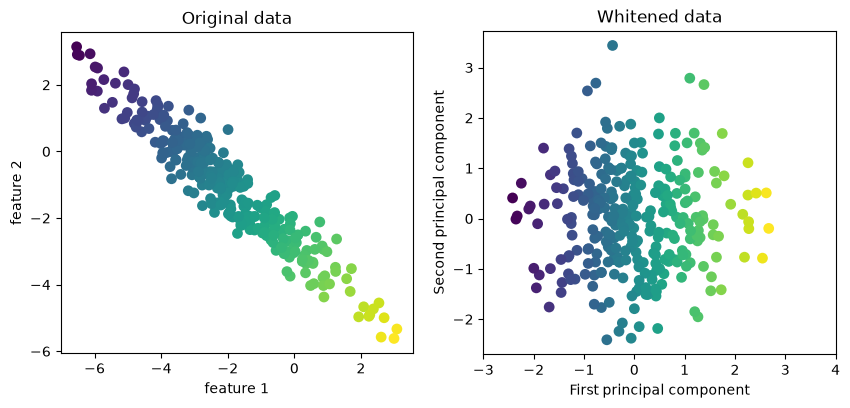

In [15]:
mglearn.plots.plot_pca_whitening() 
plt.show() 

In [16]:
pca = PCA( 
    n_components=100, 
    whiten=True, 
    random_state=0 
).fit(X_train) 
X_train_pca = pca.transform(X_train) 
X_test_pca = pca.transform(X_test) 
print( 
    "X_train_pca.shape: {}".format( 
        X_train_pca.shape 
    ) 
) 
# KNN with PCA 
knn = KNeighborsClassifier( 
    n_neighbors=1 
) 
 
knn.fit( 
    X_train_pca, 
    y_train 
) 
 
print( 
    "Test set accuracy: {:.2f}".format( 
        knn.score( 
            X_test_pca, 
            y_test 
        ) 
    ) 
) 
print( 
"pca.components_.shape: {}".format( 
pca.components_.shape )) 

X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


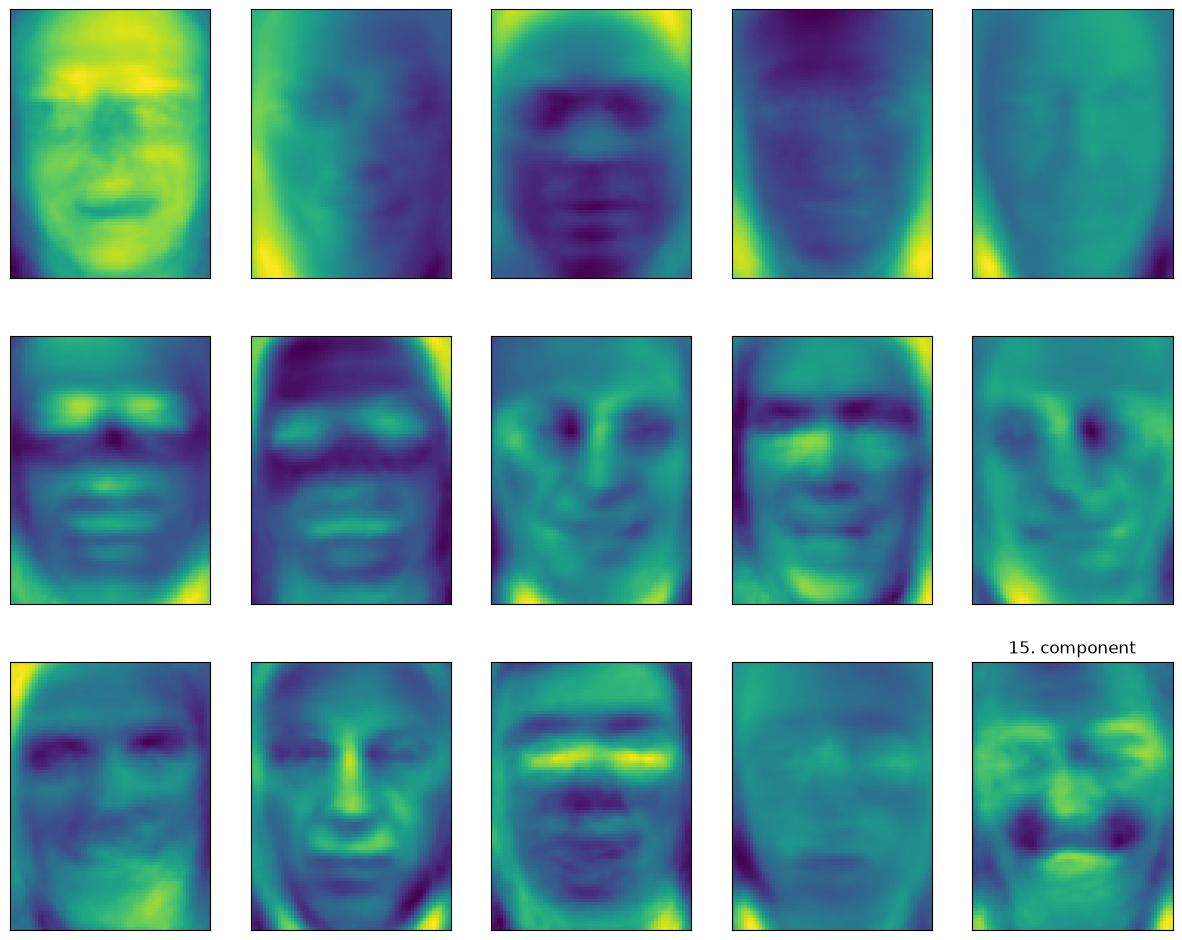

In [18]:
fix, axes = plt.subplots( 
3, 
5, 
figsize=(15,12), 
subplot_kw={'xticks':(), 'yticks':()} 
) 
for i, (component, ax) in enumerate( 
zip(pca.components_, axes.ravel())): 
 ax.imshow( 
component.reshape(image_shape), 
cmap='viridis' 
) 
ax.set_title( 
        "{}. component".format(i+1) 
    ) 
 
plt.show() 


In [19]:
# Scaling PCA features 
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform( 
    X_train_pca 
) 
X_test_scaled = scaler.transform( 
    X_test_pca 
) 


In [20]:
model = Sequential([ 
 
    Input( 
        shape=(100,) 
    ), 
 
    Dense( 
        300, 
        activation='relu' 
    ), 
 
    Dense( 
        100, 
        activation='relu' 
    ), 
 
    Dense( 
        len(np.unique(y_train)), 
        activation='softmax' 
    ) 
 
]) 


In [21]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']) 

In [22]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0181 - loss: 4.1309
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0271 - loss: 4.0902
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0304 - loss: 4.0671
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0498 - loss: 4.0402
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0672 - loss: 4.0102
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0808 - loss: 3.9773
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0911 - loss: 3.9333
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1176 - loss: 3.8767
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1506 - loss: 3.8109
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1816 - loss: 3.7189
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2023 - loss: 3.6146
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2327 - lo

In [23]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1) 
print("Test Loss:", loss) 
print("Test Accuracy:", accuracy) 


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3682 - loss: 2.7916  
Test Loss: 2.7916440963745117
Test Accuracy: 0.3682170510292053
